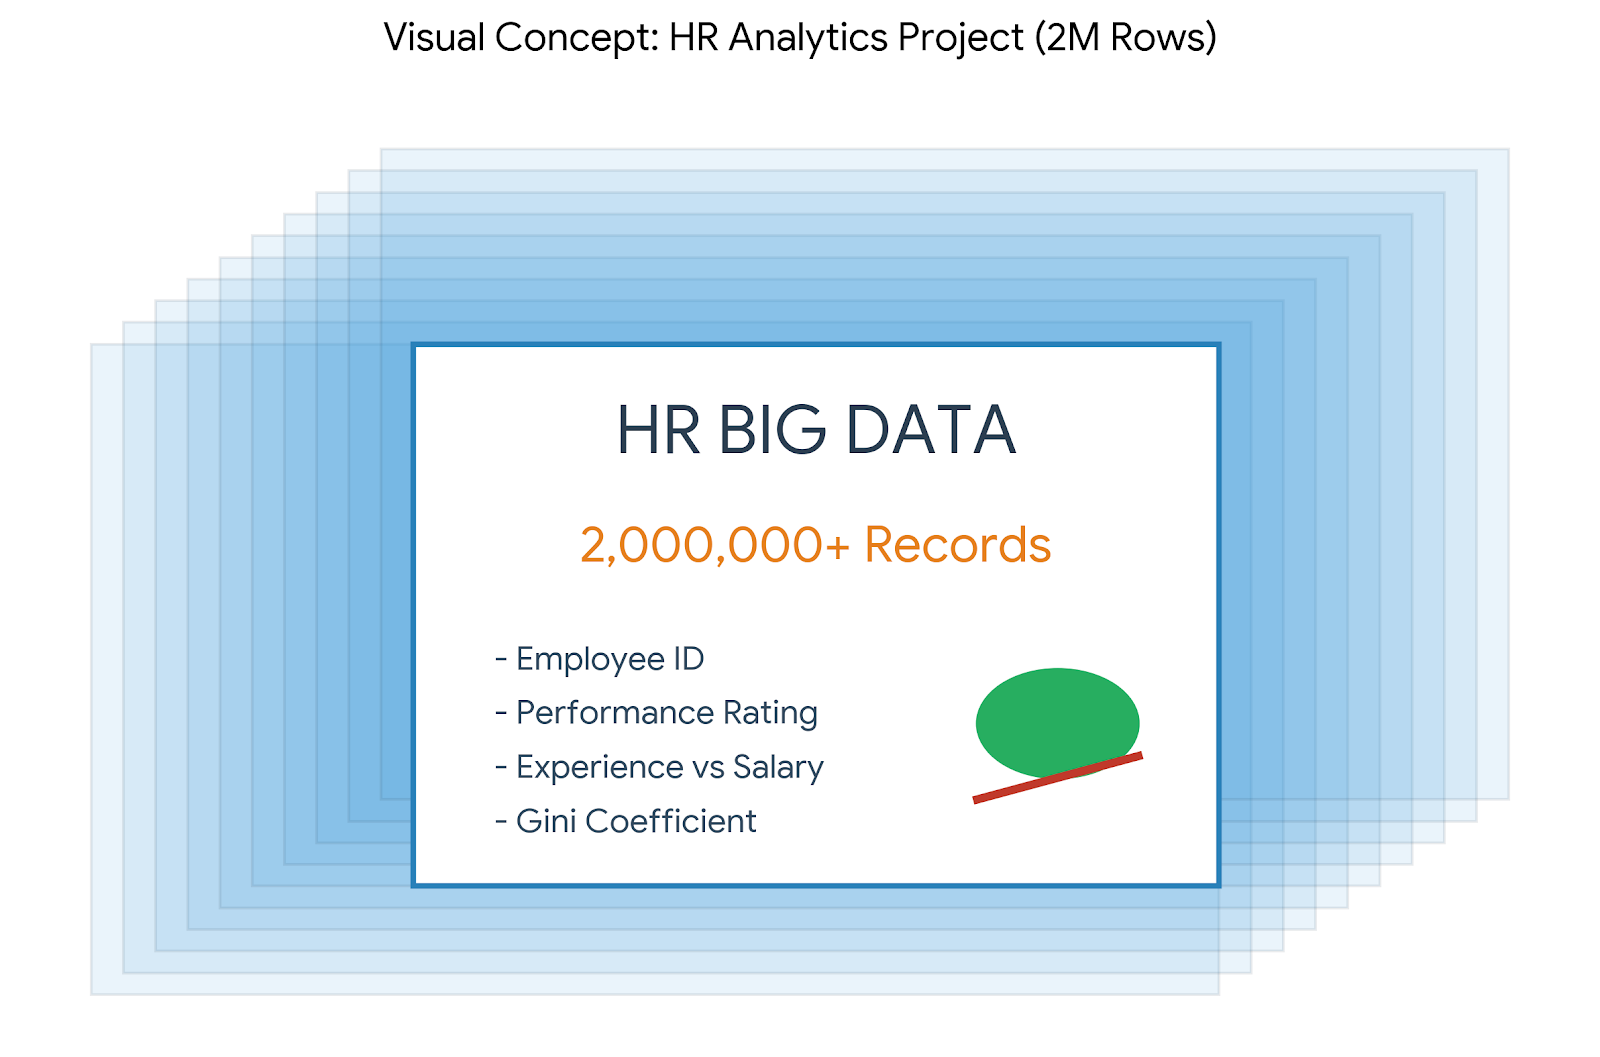

In [20]:
from IPython.display import Image, display
display(Image(filename='unnamed.png', width=800))

# HR Analytics Dashboard

This notebook analyzes a large HR dataset to explain salary structure, workforce composition, performance patterns, and income inequality.

## Business Problem

The goal is to understand what drives compensation across countries, departments, job levels, and work modes, and to quantify whether salary differences are broad-based or concentrated.

In [23]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sns.set_theme(style='whitegrid')
df=pd.read_csv('hr_raw.csv')
df

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8,Active,On-site,92992.0,2023,Germany,Munich,32,Mid
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15,Active,On-site,111121.0,2016,Spain,Seville,43,Senior
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1,Active,Hybrid,49012.0,2024,France,Marseille,23,Junior
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2,Active,On-site,57553.0,2024,United Kingdom,Edinburgh,31,Junior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,EMP1999996,Ottmar Kusch-Dörschner,IT,Software Developer,2020-11-30,Good,15,Active,Hybrid,136684.0,2020,Germany,Frankfurt,44,Senior
1999996,EMP1999997,Isis Wagenvoort,Sales,Sales Manager,2024-06-06,Good,3,Active,On-site,57911.0,2024,Netherlands,Amsterdam,25,Junior
1999997,EMP1999998,Ángel Gomez Arenas,Sales,Sales Manager,2020-05-21,Excellent,14,Active,Remote,146065.0,2020,Spain,Valencia,39,Senior
1999998,EMP1999999,Carmela Weiß,Sales,Business Development,2018-07-11,Excellent,9,Active,Remote,138855.0,2018,Germany,Frankfurt,35,Senior


In [22]:
df =df.copy()
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df['Experience_Years'] = pd.to_numeric(df['Experience_Years'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
print(df.head())

  Employee_ID                             Full_Name  Department  \
0  EMP0000001                     Heinz-Georg Eimer       Sales   
1  EMP0000002  Maartje van den Nuwenhuysen-Geertsen          HR   
2  EMP0000003                  Sara Sureda Figueroa          HR   
3  EMP0000004                          Luce Sanchez  Operations   
4  EMP0000005                      William Jennings       Sales   

              Job_Title   Hire_Date Performance_Rating  Experience_Years  \
0  Business Development  2023-01-31       Satisfactory                 8   
1            HR Manager  2008-11-07               Good                11   
2     Talent Specialist  2016-03-19  Needs Improvement                15   
3   Operations Director  2024-04-03               Good                 1   
4         Regional Lead  2024-11-17               Good                 2   

   Status Work_Mode    Salary  Year         Country       City  Age Job_Level  
0  Active   On-site   92992.0  2023         Germany     Muni

## Core Metrics

Start with the headline numbers that describe workforce scale, pay levels, and the strength of the experience-salary relationship.

In [9]:
gini_input = df['Salary'].dropna().to_numpy(dtype=float)
gini_input = np.sort(gini_input[gini_input >= 0])
num_vals = gini_input.size
idx_vals = np.arange(1, num_vals + 1)
gini_coef = (2 * np.sum(idx_vals * gini_input) / (num_vals * np.sum(gini_input))) - ((num_vals + 1) / num_vals)

kpis = pd.DataFrame({
    'Metric': ['Employees', 'Average Salary', 'Median Salary', 'Experience Salary Correlation', 'Gini Coefficient'],
    'Value': [len(df), df['Salary'].mean(), df['Salary'].median(), df[['Experience_Years', 'Salary']].dropna().corr().loc['Experience_Years', 'Salary'], gini_coef]
})
print(kpis)

                          Metric         Value
0                      Employees  2.000000e+06
1                 Average Salary  8.994836e+04
2                  Median Salary  8.082900e+04
3  Experience Salary Correlation  9.235210e-01
4               Gini Coefficient  2.690772e-01


## Salary by Department

This view shows which functions command the strongest compensation levels.

   Department        Salary
2          IT  96304.567656
0     Finance  94218.731733
4       Sales  91216.626567
3  Operations  84679.729403
1          HR  74379.262276


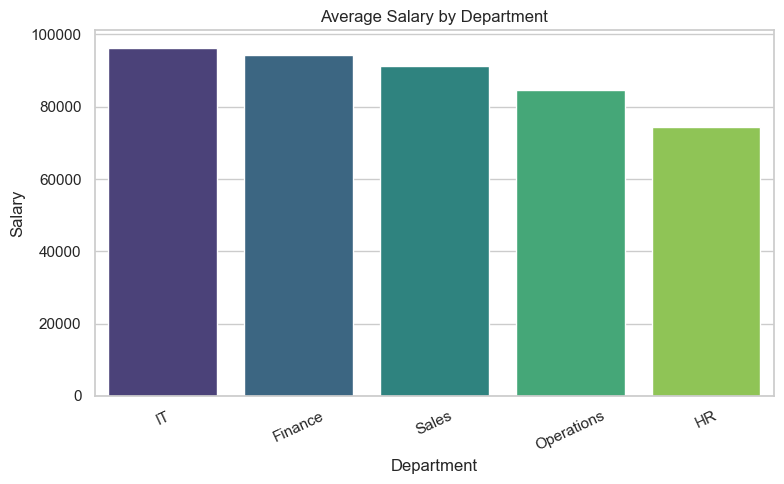

In [12]:
salary_by_department_nb = df.groupby('Department', observed=True)['Salary'].mean().reset_index().sort_values('Salary', ascending=False)
print(salary_by_department_nb)
plt.figure(figsize=(8, 5))
sns.barplot(data=salary_by_department_nb, x='Department', y='Salary', palette='viridis')
plt.title('Average Salary by Department')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Headcount by Country

This helps identify the geographic concentration of the workforce.

          Country  Employees
6  United Kingdom     499659
1         Germany     440816
0          France     400162
5           Spain     259754
2           Italy     199872
3     Netherlands     139392
4          Poland      60345


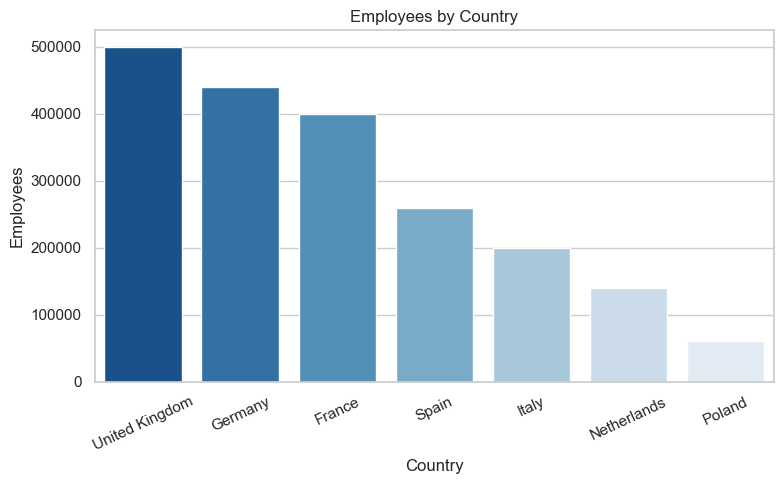

In [13]:
country_headcount_nb = df.groupby('Country', observed=True).size().reset_index(name='Employees').sort_values('Employees', ascending=False)
print(country_headcount_nb)
plt.figure(figsize=(8, 5))
sns.barplot(data=country_headcount_nb, x='Country', y='Employees', palette='Blues_r')
plt.title('Employees by Country')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Performance by Work Mode

This pivot shows how performance ratings are distributed across hybrid, on-site, and remote work arrangements.

Work_Mode           Hybrid  On-site  Remote
Performance_Rating                         
Excellent            52343   164396   82105
Good                175328   548556  275084
Needs Improvement    24362    77091   38471
Satisfactory         97920   307498  153513


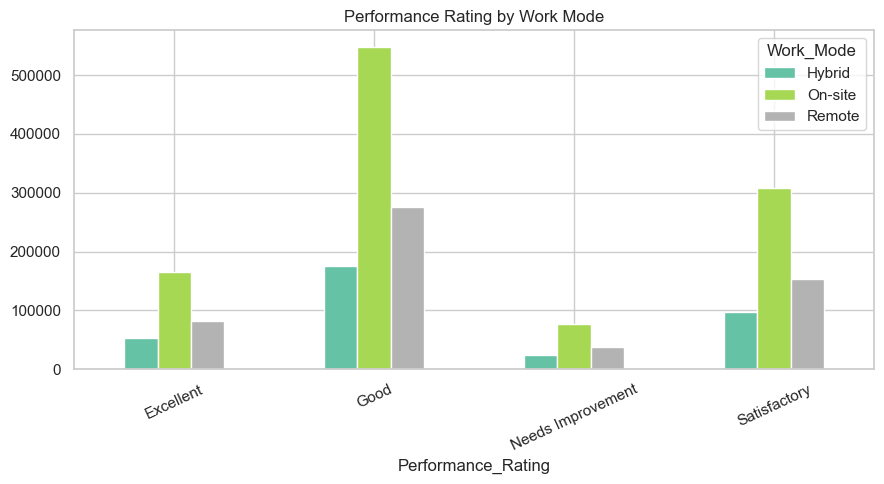

In [14]:
perf_workmode_nb = pd.crosstab(df['Performance_Rating'], df['Work_Mode'])
print(perf_workmode_nb)
perf_workmode_nb.plot(kind='bar', figsize=(9, 5), colormap='Set2')
plt.title('Performance Rating by Work Mode')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Salary vs Experience

This chart visualizes the strong positive relationship between experience and salary using a sample for readability.

         Experience_Years    Salary
1828401                15  135817.0
1200071                 0   44897.0
194849                  6   84185.0
1629054                18  219003.0
191144                  5   83537.0


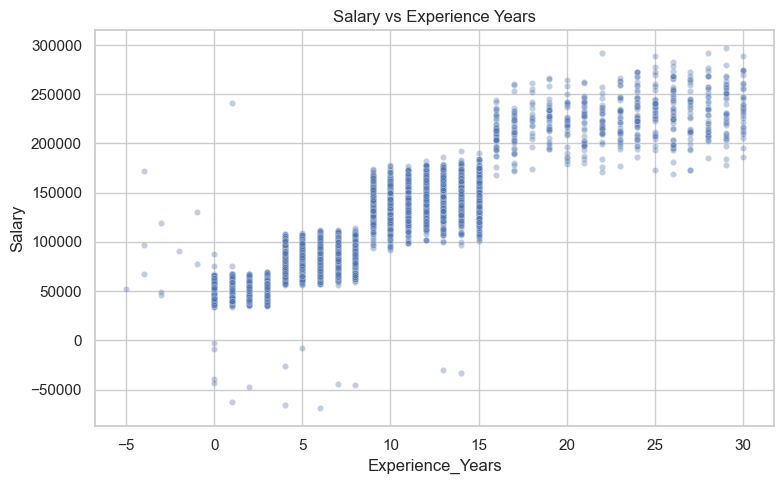

In [15]:
scatter_nb = df[['Experience_Years', 'Salary']].dropna().sample(n=10000, random_state=42)
print(scatter_nb.head())
plt.figure(figsize=(8, 5))
sns.scatterplot(data=scatter_nb, x='Experience_Years', y='Salary', alpha=0.35, s=20)
plt.title('Salary vs Experience Years')
plt.tight_layout()
plt.show()

## Top Paid Job Titles by Country

This ranks the top 5 highest-paying job titles within each country using average salary.

In [16]:
job_title_country_nb = df.groupby(['Country', 'Job_Title'], observed=True)['Salary'].mean().reset_index(name='Average_Salary')
top_5_titles_nb = job_title_country_nb.sort_values(['Country', 'Average_Salary'], ascending=[True, False]).groupby('Country', observed=True).head(5).reset_index(drop=True)
print(top_5_titles_nb.head(20))

        Country           Job_Title  Average_Salary
0        France        System Admin    96366.462421
1        France          IT Manager    96358.758261
2        France       Data Engineer    96281.560304
3        France  Software Developer    95792.960653
4        France     DevOps Engineer    95713.285446
5       Germany     DevOps Engineer    96967.792984
6       Germany        System Admin    96645.172105
7       Germany       Data Engineer    96019.211889
8       Germany  Software Developer    95995.585942
9       Germany          IT Manager    95910.954325
10        Italy     DevOps Engineer    97679.175164
11        Italy       Data Engineer    96763.108249
12        Italy        System Admin    96242.453158
13        Italy          IT Manager    96217.744557
14        Italy  Software Developer    95657.080053
15  Netherlands        System Admin    97621.648587
16  Netherlands       Data Engineer    96554.089322
17  Netherlands     DevOps Engineer    96445.605252
18  Netherla

## Economic Insight - Income Distribution

The Gini coefficient is used to summarize how equally income is distributed across employees. A value near 0 means more equality, while a value near 1 means stronger concentration.

0.26907720394892753


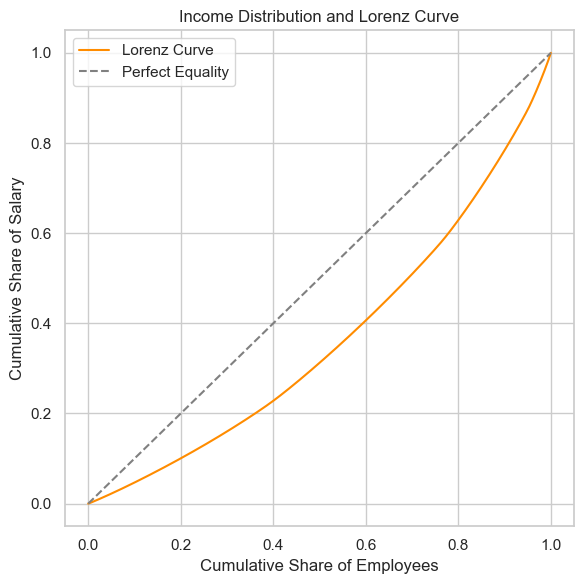

In [17]:
lorenz_df = pd.DataFrame({'Salary': gini_input})
lorenz_df['cum_salary'] = lorenz_df['Salary'].cumsum() / lorenz_df['Salary'].sum()
lorenz_df['cum_people'] = np.arange(1, len(lorenz_df) + 1) / len(lorenz_df)
print(gini_coef)
plt.figure(figsize=(6, 6))
plt.plot(lorenz_df['cum_people'], lorenz_df['cum_salary'], label='Lorenz Curve', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Equality')
plt.title('Income Distribution and Lorenz Curve')
plt.xlabel('Cumulative Share of Employees')
plt.ylabel('Cumulative Share of Salary')
plt.legend()
plt.tight_layout()
plt.show()

## Final Takeaway

IT leads salaries not because employees are dramatically more experienced, but because the pay structure of technical roles is higher across job levels and remains consistently elevated across countries. The income distribution is moderately unequal, with a Gini coefficient around 0.269, which suggests structured but not extreme dispersion.